# 0. IMPORTACIÓN DE LIBRERÍAS

En esta sección se importan las librerías necesarias para la carga y transformación de los datos, la simulación del problema de fijación dinámica de precios, el entrenamiento de los modelos de aprendizaje automático y el análisis estadístico de los resultados.

In [1]:
import json
import os
import random
import sys
import warnings
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyspark
import sklearn
import stable_baselines3
from gymnasium import spaces
from scipy.stats import poisson
from sklearn.ensemble import RandomForestRegressor
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.utils import set_random_seed

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    avg,
    col,
    count,
    countDistinct,
    datediff,
    expr,
    lit,
    round as spark_round,
    to_date,
)


SEED = 42
MAX_DIAS = 30
CAPACIDAD = 100

ELASTICIDAD_NOMINAL = -1.2
FACTOR_DEMANDA_NOMINAL = 1.0
PENALIZACION_VACIOS = 0.10

random.seed(SEED)
np.random.seed(SEED)
set_random_seed(SEED)

BASE_DIR = Path.cwd()
RUTA_CSV = BASE_DIR / "thegurus-opendata-renfe-trips.csv"

if not RUTA_CSV.exists():
    raise FileNotFoundError(
        f"No se encuentra el dataset en: {RUTA_CSV}"
    )

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="gymnasium",
)

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="pyspark",
)

print("=" * 60)
print("CONFIGURACIÓN DEL ENTORNO")
print("=" * 60)

print(f"Python:             {sys.version.split()[0]}")
print(f"NumPy:              {np.__version__}")
print(f"Pandas:             {pd.__version__}")
print(f"Scikit-learn:       {sklearn.__version__}")
print(f"PySpark:            {pyspark.__version__}")
print(f"Gymnasium:          {gym.__version__}")
print(f"Stable-Baselines3:  {stable_baselines3.__version__}")

CONFIGURACIÓN DEL ENTORNO
Python:             3.10.11
NumPy:              2.2.6
Pandas:             2.3.3
Scikit-learn:       1.7.2
PySpark:            4.2.0
Gymnasium:          1.3.0
Stable-Baselines3:  2.9.0


# 1. INGESTA Y ETL MASIVO (PYSPARK)

## Preparación y particionado de los datos

Carga, limpieza y transformación del dataset de Renfe. Se calcula el *lead time* y se construyen las particiones temporales de **Train**, **Validation** y **Test** manteniendo los servicios separados.

In [2]:
# Definición de los nombres de las columnas originales utilizadas durante el procesamiento y modelización de los datos.

COL_FECHA_COMPRA = "insert_date"
COL_FECHA_SALIDA = "departure"
COL_PRECIO = "price"
COL_ORIGEN = "origin"
COL_DESTINO = "destination"
COL_TIPO_VEHICULO = "vehicle_type"
COL_CLASE = "vehicle_class"
COL_TARIFA = "fare"


# Creación de la sesión de Spark utilizada para la lectura y procesamiento distribuido del dataset de gran tamaño.

spark = (
    SparkSession.builder
    .appName("TFM_Renfe_DynamicPricing_DRL")
    .getOrCreate()
)



# Carga del dataset original

df_raw = (
    spark.read
    .format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .option("quote", '"') 
    .option("escape", '"')
    .option("multiLine", "true")
    .load(str(RUTA_CSV))
)

# Comprobación de filas y columnas ANTES del procesamiento
filas_raw = df_raw.count()
columnas_raw = len(df_raw.columns)

print("=" * 60)
print("DIMENSIONES DEL DATASET ORIGINAL")
print("=" * 60)
print(f"Filas:    {filas_raw:,}")
print(f"Columnas: {columnas_raw}")
print("=" * 60)


# Conversión de las fechas a formato fecha y cálculo del lead time: número de días entre la compra y la salida.

from pyspark.sql.functions import translate, upper

df_clean = (
    df_raw
    .withColumn(
        COL_ORIGEN, 
        translate(upper(col(COL_ORIGEN)), 'ÁÉÍÓÚ', 'AEIOU')
    )
    .withColumn(
        COL_DESTINO, 
        translate(upper(col(COL_DESTINO)), 'ÁÉÍÓÚ', 'AEIOU')
    )
    .withColumn(
        "fecha_compra_dt",
        to_date(col(COL_FECHA_COMPRA))
    )
    .withColumn(
        "fecha_salida_dt",
        to_date(col(COL_FECHA_SALIDA))
    )
    .withColumn(
        "lead_time_dias",
        datediff(
            col("fecha_salida_dt"),
            col("fecha_compra_dt")
        )
    )
    .filter(
        col("lead_time_dias").between(0, MAX_DIAS)
    )
    .filter(
        col(COL_PRECIO).isNotNull()
        & (col(COL_PRECIO) > 0)
    )
    .dropna(
        subset=[
            COL_ORIGEN,
            COL_DESTINO,
            COL_TIPO_VEHICULO,
            COL_CLASE,
            COL_TARIFA,
            "fecha_salida_dt",
            "fecha_compra_dt",
        ]
    )
    .cache()
)


# Se eliminan las fechas nulas y se ordenan cronológicamente.

fechas_salida = [
    fila["fecha_salida_dt"]
    for fila in (
        df_clean
        .select("fecha_salida_dt")
        .where(
            col("fecha_salida_dt").isNotNull()
        )
        .distinct()
        .orderBy("fecha_salida_dt")
        .collect()
    )
]


if len(fechas_salida) < 3:
    raise ValueError(
        "No hay suficientes fechas de salida distintas para crear las particiones Train, Validation y Test."
    )


# Se utilizan aproximadamente:
# - 70 % de las fechas de salida para Train
# - 10 % para Validation
# - 20 % para Test

idx_fin_train = max(
    1,
    int(0.70 * len(fechas_salida))
)

idx_fin_val = min(
    max(
        idx_fin_train + 1,
        int(0.80 * len(fechas_salida))
    ),
    len(fechas_salida) - 1
)


fecha_corte_train = fechas_salida[idx_fin_train]
fecha_corte_test = fechas_salida[idx_fin_val]


# Crear las particiones definitivas

df_train_raw = df_clean.filter(
    col("fecha_salida_dt") < lit(fecha_corte_train)
)

df_val_raw = df_clean.filter(
    (col("fecha_salida_dt") >= lit(fecha_corte_train))
    & (
        col("fecha_salida_dt")
        < lit(fecha_corte_test)
    )
)

df_test_raw = df_clean.filter(
    col("fecha_salida_dt") >= lit(fecha_corte_test)
)


# Comprobar que las particiones no están vacías

n_train = df_train_raw.count()
n_val = df_val_raw.count()
n_test = df_test_raw.count()

if n_train == 0:
    raise ValueError(
        "La partición TRAIN está vacía."
    )

if n_val == 0:
    raise ValueError(
        "La partición VALIDATION está vacía."
    )

if n_test == 0:
    raise ValueError(
        "La partición TEST está vacía."
    )


# Comprobación de solapamiento entre particiones. El resultado correcto debe ser cero en los tres cruces.

CLAVES_SERVICIO = [
    COL_ORIGEN,
    COL_DESTINO,
    "fecha_salida_dt",
]


# Obtener los servicios de cada partición

train_servicios = (
    df_train_raw
    .select(*CLAVES_SERVICIO)
    .dropDuplicates()
)

val_servicios = (
    df_val_raw
    .select(*CLAVES_SERVICIO)
    .dropDuplicates()
)

test_servicios = (
    df_test_raw
    .select(*CLAVES_SERVICIO)
    .dropDuplicates()
)


# Calcular el solapamiento

solapamiento_train_val = (
    train_servicios
    .intersect(val_servicios)
    .count()
)

solapamiento_train_test = (
    train_servicios
    .intersect(test_servicios)
    .count()
)

solapamiento_val_test = (
    val_servicios
    .intersect(test_servicios)
    .count()
)


# Mostrar el resultado del diagnóstico

print("=" * 80)
print("COMPROBACIÓN DE SOLAPAMIENTO ENTRE PARTICIONES")
print("=" * 80)

print(
    "Servicios compartidos entre TRAIN y VALIDATION:",
    solapamiento_train_val,
)

print(
    "Servicios compartidos entre TRAIN y TEST:",
    solapamiento_train_test,
)

print(
    "Servicios compartidos entre VALIDATION y TEST:",
    solapamiento_val_test,
)


if (
    solapamiento_train_val == 0
    and solapamiento_train_test == 0
    and solapamiento_val_test == 0
):
    print(
        "OK: no existe solapamiento de servicios "
        "entre las particiones."
    )
else:
    raise ValueError(
        "Sigue existiendo solapamiento de servicios. "
        "Revisa la clave del servicio y la fecha de salida."
    )


# Resumen de la división temporal

print()
print("=" * 80)
print("DIVISIÓN TEMPORAL DEL EXPERIMENTO")
print("=" * 80)

print(
    "Train:       fecha_salida <",
    fecha_corte_train,
)

print(
    "Validation:  ",
    fecha_corte_train,
    "<= fecha_salida <",
    fecha_corte_test,
)

print(
    "Test:        fecha_salida >=",
    fecha_corte_test,
)

print()
print("Registros Train:", n_train)
print("Registros Validation:", n_val)
print("Registros Test:", n_test)

print()
print(
    "Train / Validation / Test preparados utilizando "
    "fechas de salida completas."
)
    

# Construcción de una función para resumir el comportamiento histórico de los precios por ruta, lead time, tipo de vehículo, clase y tarifa.

def agregar_precios(df):
    return (
        df
        .groupBy(
            COL_ORIGEN,
            COL_DESTINO,
            "lead_time_dias",
            COL_TIPO_VEHICULO,
            COL_CLASE,
            COL_TARIFA,
        )
        .agg(
            count("*").alias("n_observaciones_precio"),
            spark_round(
                avg(COL_PRECIO),
                2
            ).alias("precio_medio"),
            expr(
                f"percentile_approx({COL_PRECIO}, 0.5)"
            ).alias("precio_mediano"),
            spark_round(
                expr(f"stddev({COL_PRECIO})"),
                2
            ).alias("precio_std"),
            expr(
                f"max({COL_PRECIO})"
            ).alias("precio_maximo"),
        )
    )


# La agregación de precios se realiza por separado sobre TRAIN, VALIDATION y TEST para mantener la independencia entre las distintas etapas del experimento.

df_precios_train_pd = agregar_precios(
    df_train_raw
).toPandas()

df_precios_val_pd = agregar_precios(
    df_val_raw
).toPandas()

df_precios_test_pd = agregar_precios(
    df_test_raw
).toPandas()


# Creación de la trayectoria de precio base asociada a una ruta.

def crear_referencia_precio(
    df,
    origen="MADRID",
    destino="BARCELONA",
):
    ruta = df[
        (df[COL_ORIGEN] == origen)
        & (df[COL_DESTINO] == destino)
    ].copy()

    if ruta.empty:
        raise ValueError(
            f"No hay precios para la ruta "
            f"{origen}-{destino}."
        )

    tarifa_maxima_historica = float(
        ruta["precio_maximo"].max()
    )

    ruta["precio_ponderado"] = (
        ruta["precio_mediano"]
        * ruta["n_observaciones_precio"]
    )

    referencia = (
        ruta
        .groupby("lead_time_dias")[
            [
                "precio_ponderado",
                "n_observaciones_precio",
            ]
        ]
        .sum()
    )

    referencia["precio_base"] = (
        referencia["precio_ponderado"]
        / referencia["n_observaciones_precio"]
    )

    referencia = (
        referencia
        .reset_index()[
            ["lead_time_dias", "precio_base"]
        ]
    )

    dias_completos = pd.DataFrame(
        {
            "lead_time_dias": np.arange(
                0,
                MAX_DIAS + 1,
            )
        }
    )

    referencia = dias_completos.merge(
        referencia,
        on="lead_time_dias",
        how="left",
    )

    precio_global = (
        ruta["precio_ponderado"].sum()
        / ruta["n_observaciones_precio"].sum()
    )

    referencia["precio_base"] = (
        referencia["precio_base"]
        .interpolate()
        .bfill()
        .ffill()
        .fillna(precio_global)
    )

    return (
        referencia,
        tarifa_maxima_historica,
    )


# Construcción independiente de la referencia de precios para TRAIN, VALIDATION y TEST.

referencia_precio_train, tarifa_max_train = crear_referencia_precio(
    df_precios_train_pd
)

referencia_precio_val, tarifa_max_val = crear_referencia_precio(
    df_precios_val_pd
)

referencia_precio_test, tarifa_max_test = crear_referencia_precio(
    df_precios_test_pd
)


# Estimación de la actividad de compra histórica de una ruta en función del lead time.

def crear_perfil_demanda(
    df_spark,
    origen="MADRID",
    destino="BARCELONA",
    demanda_media_objetivo=3.0,
):
    ruta = df_spark.filter(
        (col(COL_ORIGEN) == origen)
        & (col(COL_DESTINO) == destino)
    )

    actividad = (
        ruta
        .groupBy(
            "fecha_salida_dt",
            "lead_time_dias",
        )
        .agg(
            countDistinct(
                COL_FECHA_COMPRA
            ).alias("n_snapshots")
        )
    )

    perfil = (
        actividad
        .groupBy("lead_time_dias")
        .agg(
            avg("n_snapshots").alias(
                "actividad_media"
            )
        )
        .toPandas()
    )

    dias_completos = pd.DataFrame(
        {
            "lead_time_dias": np.arange(
                1,
                MAX_DIAS + 1,
            )
        }
    )

    perfil = dias_completos.merge(
        perfil,
        on="lead_time_dias",
        how="left",
    )

    perfil["actividad_media"] = (
        perfil["actividad_media"]
        .interpolate()
        .bfill()
        .ffill()
        .fillna(0.0)
    )


    # Función decreciente que aproxima el aumento de urgencia a medida que disminuye el tiempo restante hasta la salida.

    perfil["urgencia"] = np.exp(
        -perfil["lead_time_dias"] / 15.0
    )


    # Demanda base

    perfil["demanda_base"] = (
        perfil["actividad_media"]
        * perfil["urgencia"]
    )

    media_demanda_base = (
        perfil["demanda_base"].mean()
    )

    if media_demanda_base <= 0:
        raise ValueError(
            "La demanda base no permite "
            "calibrar el perfil de demanda."
        )


    # Calibración de la demanda
  
    perfil["demanda_media"] = (
        perfil["demanda_base"]
        / media_demanda_base
    ) * demanda_media_objetivo

    return perfil[
        [
            "lead_time_dias",
            "demanda_media",
        ]
    ]


# Perfiles de demanda por partición
# Construcción independiente del perfil de demanda para TRAIN, VALIDATION y TEST.

perfil_demanda_train = crear_perfil_demanda(
    df_train_raw
)

perfil_demanda_val = crear_perfil_demanda(
    df_val_raw
)

perfil_demanda_test = crear_perfil_demanda(
    df_test_raw
)


# Normalización global basada exclusivamente en TRAIN
# Se utiliza el máximo histórico de TRAIN como escala de normalización de precios.

ESCALA_PRECIO_TRAIN = float(tarifa_max_train)

if ESCALA_PRECIO_TRAIN <= 0:
    raise ValueError(
        "La escala de normalización derivada de TRAIN "
        "debe ser positiva."
    )


# Presentación de los puntos de corte utilizados en el experimento y comprobación de que TEST permanece separado del entrenamiento y de la selección del modelo.

print("=" * 80)
print("DIVISIÓN TEMPORAL DEL EXPERIMENTO")
print("=" * 80)

print(
    f"Train:       < {fecha_corte_train}"
)

print(
    f"Validation:  {fecha_corte_train} "
    f"<= fecha < {fecha_corte_test}"
)

print(
    f"Test:        >= {fecha_corte_test}"
)


# Visualización de la escala de precios utilizada por el entorno.

print("\nEscala de normalización:")
print(
    f"ESCALA_PRECIO_TRAIN = "
    f"{ESCALA_PRECIO_TRAIN:.2f} €"
)


# Mensaje de control para dejar constancia de que los conjuntos Train, Validation y Test han sido preparados respetando la separación temporal.

print(
    "\nTrain / Validation / Test preparados "
    "sin utilizar información de TEST para "
    "entrenamiento o selección del modelo."
)

DIMENSIONES DEL DATASET ORIGINAL
Filas:    38,753,060
Columnas: 14
COMPROBACIÓN DE SOLAPAMIENTO ENTRE PARTICIONES
Servicios compartidos entre TRAIN y VALIDATION: 0
Servicios compartidos entre TRAIN y TEST: 0
Servicios compartidos entre VALIDATION y TEST: 0
OK: no existe solapamiento de servicios entre las particiones.

DIVISIÓN TEMPORAL DEL EXPERIMENTO
Train:       fecha_salida < 2020-03-30
Validation:   2020-03-30 <= fecha_salida < 2020-07-06
Test:        fecha_salida >= 2020-07-06

Registros Train: 13469102
Registros Validation: 784604
Registros Test: 1604424

Train / Validation / Test preparados utilizando fechas de salida completas.
DIVISIÓN TEMPORAL DEL EXPERIMENTO
Train:       < 2020-03-30
Validation:  2020-03-30 <= fecha < 2020-07-06
Test:        >= 2020-07-06

Escala de normalización:
ESCALA_PRECIO_TRAIN = 342.80 €

Train / Validation / Test preparados sin utilizar información de TEST para entrenamiento o selección del modelo.


### Rutas disponibles

Comprobación de las rutas origen–destino presentes en el conjunto de datos limpio.

In [3]:
total_rutas = df_clean.select(COL_ORIGEN, COL_DESTINO).dropDuplicates().count()
print(f"Total de rutas únicas en todo el dataset (df_clean): {total_rutas}")

lista_rutas = (
    df_clean.select(COL_ORIGEN, COL_DESTINO)
    .dropDuplicates()
    .sort(COL_ORIGEN, COL_DESTINO)
    .collect()
)

print("\nLista completa de rutas en tu proyecto:")
for fila in lista_rutas:
    print(f"{fila[COL_ORIGEN]} - {fila[COL_DESTINO]}")

Total de rutas únicas en todo el dataset (df_clean): 56

Lista completa de rutas en tu proyecto:
ALBACETE - MADRID
ALICANTE - MADRID
BARCELONA - MADRID
BARCELONA - VALENCIA
BARCELONA - ZARAGOZA
CADIZ - MADRID
CASTELLO - MADRID
CASTELLON - MADRID
CIUDAD REAL - MADRID
CORDOBA - MADRID
CUENCA - MADRID
GIRONA - MADRID
GRANADA - MADRID
GUADALAJARA - MADRID
HUESCA - MADRID
LEON - MADRID
LLEIDA - MADRID
MADRID - ALBACETE
MADRID - ALICANTE
MADRID - BARCELONA
MADRID - CADIZ
MADRID - CASTELLO
MADRID - CASTELLON
MADRID - CIUDAD REAL
MADRID - CORDOBA
MADRID - CUENCA
MADRID - GIRONA
MADRID - GRANADA
MADRID - GUADALAJARA
MADRID - HUESCA
MADRID - LEON
MADRID - LLEIDA
MADRID - MALAGA
MADRID - PALENCIA
MADRID - PONFERRADA
MADRID - SEGOVIA
MADRID - SEVILLA
MADRID - TARRAGONA
MADRID - TOLEDO
MADRID - VALENCIA
MADRID - VALLADOLID
MADRID - ZAMORA
MADRID - ZARAGOZA
MALAGA - MADRID
PALENCIA - MADRID
PONFERRADA - MADRID
SEGOVIA - MADRID
SEVILLA - MADRID
TARRAGONA - MADRID
TOLEDO - MADRID
VALENCIA - BARCELONA


# 2. ENTORNO DE SIMULACIÓN AVANZADO (GYMNASIUM)

## Entorno de simulación

Definición del entorno de pricing dinámico y de las variables necesarias para representar el proceso de decisión.

In [4]:
class RenfePricingEnv(gym.Env):
    """
    Entorno Gymnasium para optimización dinámica de precios mediante aprendizaje por refuerzo.
    El agente selecciona un multiplicador sobre el precio base en cada día restante hasta la salida del tren.
    """

    metadata = {"render_modes": []}


    def __init__(
        self,
        referencia_precios,
        perfil_demanda,
        tarifa_maxima=300.0,
        escala_precio=None,
        demanda_total_escenario=1.0,
        elasticidad=-0.8,
        capacidad=100,
        max_dias=30,
        penalizacion_vacios=0.10,
        potencial_dp=None,
        coef_reward_shaping=0.0,
    ):
        super().__init__()


        self.referencia_precios = referencia_precios.copy()
        self.perfil_demanda = perfil_demanda.copy()

        # Tarifa máxima permitida para limitar el precio final.

        self.tarifa_maxima = float(tarifa_maxima)

        # Escala utilizada para normalizar las observaciones y las recompensas.

        self.escala_precio = float(
            escala_precio
            if escala_precio is not None
            else tarifa_maxima
        )


        if self.tarifa_maxima <= 0:
            raise ValueError(
                "tarifa_maxima debe ser positiva."
            )

        if self.escala_precio <= 0:
            raise ValueError(
                "escala_precio debe ser positiva."
            )

        # Factor utilizado para representar diferentes niveles globales de demanda en los distintos escenarios.

        self.demanda_total_escenario = float(
            demanda_total_escenario
        )

        # Elasticidad precio de la demanda.

        self.elasticidad = float(elasticidad)


        self.capacidad = int(capacidad)
        self.max_dias = int(max_dias)
        self.penalizacion_vacios = float(
            penalizacion_vacios
        )

         # V_dp procede exclusivamente de TRAIN.

        self.potencial_dp = potencial_dp

        self.coef_reward_shaping = float(
            coef_reward_shaping
        )

        if (
            self.coef_reward_shaping < 0
        ):
            raise ValueError(
                "coef_reward_shaping no puede ser negativo."
            )

        if (
            self.coef_reward_shaping > 0
            and self.potencial_dp is None
        ):
            raise ValueError(
                "potencial_dp debe proporcionarse cuando se utiliza reward shaping."
            )


        if self.capacidad <= 0:
            raise ValueError(
                "capacidad debe ser positiva."
            )

        if self.max_dias <= 0:
            raise ValueError(
                "max_dias debe ser positivo."
            )

        if self.penalizacion_vacios < 0:
            raise ValueError(
                "penalizacion_vacios no puede ser negativa."
            )


        self.multiplicadores = np.array(
            [
                0.6,
                0.7,
                0.8,
                0.9,
                1.0,
                1.1,
                1.2,
                1.3,
                1.4,
            ],
            dtype=np.float32,
        )


        self.action_space = spaces.Discrete(
            len(self.multiplicadores)
        )

         # El agente recibe un estado de tres variables:

        self.observation_space = spaces.Box(
            low=np.zeros(
                3,
                dtype=np.float32,
            ),
            high=np.ones(
                3,
                dtype=np.float32,
            ),
            dtype=np.float32,
        )


        self.precio_por_dia = {
            int(dia): float(precio)
            for dia, precio in zip(
                self.referencia_precios["lead_time_dias"],
                self.referencia_precios["precio_base"],
            )
        }

        # Precio utilizado como fallback cuando no existe un precio específico para un determinado lead time.

        self.precio_fallback = float(
            self.referencia_precios["precio_base"].median()
        )


        self.demanda_por_dia = {
            int(dia): float(demanda)
            for dia, demanda in zip(
                self.perfil_demanda["lead_time_dias"],
                self.perfil_demanda["demanda_media"],
            )
        }

        # Factor global utilizado para modificar la intensidad de demanda según el escenario considerado.

        self.factor_demanda = (
            self.demanda_total_escenario
        )


        self.dias_restantes = self.max_dias
        self.asientos_libres = self.capacidad


    def precio_base(self, dias_restantes):
        """
        Devuelve el precio base correspondiente al lead time. Si no existe, utiliza el precio mediano como fallback.
        """

        return float(
            self.precio_por_dia.get(
                int(dias_restantes),
                self.precio_fallback,
            )
        )

    # La demanda esperada depende de cuatro componentes:

    # La demanda esperada depende de:

    def demanda_esperada(
        self,
        dias_restantes,
        action,
    ):
        """
        Calcula la demanda esperada para una acción concreta.
        La urgencia temporal ya está incluida en el perfil histórico de demanda.
        """


        precio_base = self.precio_base(
            dias_restantes
        )

        multiplicador = float(
            self.multiplicadores[action]
        )

        precio_final = min(
            precio_base * multiplicador,
            self.tarifa_maxima,
        )

        # Se obtiene la demanda media estimada para el lead time.

        lambda_historica = (
            self.demanda_por_dia.get(
                int(dias_restantes),
                0.0,
            )
        )

        # Permite simular escenarios de demanda baja, media o alta.

        lambda_base = (
            lambda_historica
            * self.factor_demanda
        )

        # Una elasticidad negativa implica que un aumento del precio

        ratio_precio = (
            precio_final
            / max(precio_base, 1e-6)
        )

        factor_precio = (
            ratio_precio
            ** self.elasticidad
        )


        lambda_demanda = (
            lambda_base
            * factor_precio
        )

        return max(
            float(lambda_demanda),
            0.0,
        )

    # Transformación del estado interno del entorno en el vector normalizado que recibe el agente PPO.

    def get_observacion(self):
        """
        Construye el estado normalizado que recibe el agente.
        """


        precio_base_actual = self.precio_base(
            self.dias_restantes
        )

        # La normalización se realiza mediante la escala obtenida exclusivamente de TRAIN.

        precio_base_norm = (
            precio_base_actual
            / self.escala_precio
        )


        precio_base_norm = float(
            np.clip(
                precio_base_norm,
                0.0,
                1.0,
            )
        )


        ocupacion = (
            1.0
            - (
                self.asientos_libres
                / self.capacidad
            )
        )

# # El agente recibe:

        return np.array(
            [
                self.dias_restantes
                / float(self.max_dias),

                ocupacion,

                precio_base_norm,
            ],
            dtype=np.float32,
        )


    def reset(self, seed=None, options=None):
        """
        Reinicia el episodio.
        """

        super().reset(seed=seed)

        self.dias_restantes = self.max_dias
        self.asientos_libres = self.capacidad

        return (
            self.get_observacion(),
            {},
        )


    def valor_potencial(self, dias_restantes, asientos_libres):
        """Devuelve V_dp(días, asientos libres) cuando está disponible."""

        if self.potencial_dp is None:
            return 0.0

        dias = int(
            np.clip(
                dias_restantes,
                0,
                self.max_dias,
            )
        )

        asientos = int(
            np.clip(
                asientos_libres,
                0,
                self.capacidad,
            )
        )

        return float(
            self.potencial_dp[
                dias,
                asientos,
            ]
        )


    def step(self, action):
        """
        Ejecuta una acción del agente.

        La acción determina el multiplicador aplicado al
        precio base del día actual.
        """

        # Se comprueba que la acción proporcionada pertenece al espacio discreto definido para el entorno.

        action = int(action)

        if not self.action_space.contains(action):
            raise ValueError(
                f"Acción inválida: {action}"
            )

        potencial_antes = self.valor_potencial(
            self.dias_restantes,
            self.asientos_libres,
        )


        precio_base = self.precio_base(
            self.dias_restantes
        )

        multiplicador = float(
            self.multiplicadores[action]
        )

        precio_final = min(
            precio_base * multiplicador,
            self.tarifa_maxima,
        )


        lambda_demanda = self.demanda_esperada(
            self.dias_restantes,
            action,
        )


        demanda_real = int(
            self.np_random.poisson(
                lambda_demanda
            )
        )


        entradas_vendidas = min(
            demanda_real,
            self.asientos_libres,
        )


        self.asientos_libres -= (
            entradas_vendidas
        )


        ingreso_paso = float(
            entradas_vendidas
            * precio_final
        )


        self.dias_restantes -= 1


        terminated = bool(
            self.dias_restantes <= 0
            or self.asientos_libres <= 0
        )

        truncated = False


        penalizacion = 0.0

        if (
            terminated
            and self.asientos_libres > 0
        ):
            penalizacion = float(
                self.asientos_libres
                * self.precio_fallback
                * self.penalizacion_vacios
            )


        reward_euros = (
            ingreso_paso
            - penalizacion
        )

        potencial_despues = self.valor_potencial(
            self.dias_restantes,
            self.asientos_libres,
        )

        reward_shaping_euros = (
            self.coef_reward_shaping
            * (
                potencial_despues
                - potencial_antes
            )
        )

        reward_total_euros = (
            reward_euros
            + reward_shaping_euros
        )

        # La recompensa se normaliza mediante la escala obtenida

        reward = (
            reward_total_euros
            / self.escala_precio
        )

        # Se almacenan variables auxiliares para facilitar el análisis posterior del comportamiento del agente.

        info = {
            "precio_base": precio_base,
            "precio_final": precio_final,
            "multiplicador": multiplicador,
            "demanda_esperada": lambda_demanda,
            "demanda_real": demanda_real,
            "entradas_vendidas": entradas_vendidas,
            "ingreso_paso": ingreso_paso,
            "penalizacion_final": penalizacion,
            "reward_euros": reward_euros,
            "potencial_antes": potencial_antes,
            "potencial_despues": potencial_despues,
            "reward_shaping_euros": reward_shaping_euros,
            "reward_total_euros": reward_total_euros,
            "asientos_libres": self.asientos_libres,
        }


        return (
            self.get_observacion(),
            float(reward),
            terminated,
            truncated,
            info,
        )


# Se crea una instancia del entorno utilizando los parámetros nominales y los datos de TRAIN.

env_check = RenfePricingEnv(
    referencia_precios=referencia_precio_train,
    perfil_demanda=perfil_demanda_train,
    tarifa_maxima=tarifa_max_train,
    escala_precio=ESCALA_PRECIO_TRAIN,
    demanda_total_escenario=FACTOR_DEMANDA_NOMINAL,
    elasticidad=ELASTICIDAD_NOMINAL,
    capacidad=CAPACIDAD,
    max_dias=MAX_DIAS,
    penalizacion_vacios=PENALIZACION_VACIOS,
)



check_env(
    env_check,
    warn=True,
)


# Cierre del entorno utilizado para la validación.

env_check.close()



print(
    "El entorno Gymnasium ha superado check_env."
)

El entorno Gymnasium ha superado check_env.


### Referencia teórica

Obtención del óptimo mediante Programación Dinámica para disponer de una referencia teórica independiente.

In [5]:
def calcular_optimo_dp(entorno):

    max_dias = entorno.max_dias
    capacidad = entorno.capacidad
    acciones = entorno.multiplicadores

    V = np.zeros((max_dias + 1, capacidad + 1), dtype=np.float64)
    politica = np.zeros((max_dias + 1, capacidad + 1), dtype=np.int32)

    for c in range(capacidad + 1):
        V[0, c] = -c * entorno.precio_fallback * entorno.penalizacion_vacios

    for d in range(1, max_dias + 1):
        for c in range(capacidad + 1):

            # Si no quedan asientos, el episodio termina. 
            if c == 0:
                V[d, c] = 0.0
                politica[d, c] = 0
                continue

            valores = np.zeros(len(acciones))

            for a in range(len(acciones)):
                precio_base = entorno.precio_base(d)
                multiplicador = float(acciones[a])

                precio = min(
                    precio_base * multiplicador,
                    entorno.tarifa_maxima,
                )

                lam = entorno.demanda_esperada(d, a)
                valor = 0.0

                if lam > 0:
                    dem_array = np.arange(c)
                    
                    probs = poisson.pmf(dem_array, lam)
                    valores_futuros = V[d - 1, c - dem_array]
                    
                    valor += np.sum(probs * (dem_array * precio + valores_futuros))

                    prob_agotar = poisson.sf(c - 1, lam)
                    valor += prob_agotar * (c * precio + V[d - 1, 0])
                else:
                    # Si lambda es 0, no hay ventas con 100% de probabilidad
                    valor += V[d - 1, c]

                valores[a] = valor

            politica[d, c] = int(np.argmax(valores))
            V[d, c] = float(np.max(valores))

    return V, politica

### Validación del entorno

Comprobación de la compatibilidad del entorno con Gymnasium antes del entrenamiento.

In [6]:

# check_env realiza comprobaciones automáticas sobre el entorno, verificando aspectos como:

check_env(
    env_check,
    warn=True,
)


# Una vez finalizada la validación, se cierra la instancia utilizada para evitar mantener recursos innecesariamente.

env_check.close()



print(
    "El entorno Gymnasium ha superado check_env."
)

El entorno Gymnasium ha superado check_env.


### Política óptima mediante Programación Dinámica

Cálculo de la política óptima para el escenario nominal.

In [7]:
# Se crea una instancia del entorno utilizando los datos y parámetros del escenario nominal de TRAIN.

env_dp = RenfePricingEnv(
    referencia_precios=referencia_precio_train,
    perfil_demanda=perfil_demanda_train,
    tarifa_maxima=tarifa_max_train,
    escala_precio=ESCALA_PRECIO_TRAIN,
    demanda_total_escenario=FACTOR_DEMANDA_NOMINAL,
    elasticidad=ELASTICIDAD_NOMINAL,
    capacidad=CAPACIDAD,
    max_dias=MAX_DIAS,
    penalizacion_vacios=PENALIZACION_VACIOS,
)


# La función calcular_optimo_dp determina:

V_dp, politica_dp = calcular_optimo_dp(
    env_dp
)



acciones, frecuencias = np.unique(
    politica_dp,
    return_counts=True
)



print("Acciones utilizadas por el óptimo:\n")

for accion, frecuencia in zip(
    acciones,
    frecuencias
):
    print(
        f"Acción {accion}: "
        f"{frecuencia} estados"
    )



print(
    "\nNúmero de acciones distintas:",
    len(acciones)
)

Acciones utilizadas por el óptimo:

Acción 0: 634 estados
Acción 1: 79 estados
Acción 2: 116 estados
Acción 3: 148 estados
Acción 4: 189 estados
Acción 5: 167 estados
Acción 6: 122 estados
Acción 7: 81 estados
Acción 8: 1595 estados

Número de acciones distintas: 9


### Análisis de la política óptima

Estudio de la distribución de acciones y de su evolución a lo largo del horizonte temporal.

In [8]:

politica_util = politica_dp[1:, 1:]



acciones, frecuencias = np.unique(
    politica_util,
    return_counts=True
)


# Para cada acción se muestra:

for accion, frecuencia in zip(acciones, frecuencias):
    print(
        f"Acción {accion}: "
        f"{frecuencia} estados "
        f"({frecuencia / politica_util.size * 100:.2f}%)"
    )



print(
    "\nNúmero de acciones distintas:",
    len(acciones)
)

Acción 0: 503 estados (16.77%)
Acción 1: 79 estados (2.63%)
Acción 2: 116 estados (3.87%)
Acción 3: 148 estados (4.93%)
Acción 4: 189 estados (6.30%)
Acción 5: 167 estados (5.57%)
Acción 6: 122 estados (4.07%)
Acción 7: 81 estados (2.70%)
Acción 8: 1595 estados (53.17%)

Número de acciones distintas: 9


### Evolución de las acciones

Comparación de las decisiones óptimas para distintos valores del tiempo restante.

In [9]:
# Se analiza qué acciones de pricing forman parte de la política óptima para distintos momentos del horizonte temporal.

for d in [1, 5, 10, 15, 20, 25, 30]:
    print(
        f"Días={d}: "
        f"acciones={np.unique(politica_dp[d, 1:])}"
    )

Días=1: acciones=[0 1 2 3 4 5 6 8]
Días=5: acciones=[0 1 2 3 4 5 6 7 8]
Días=10: acciones=[0 1 2 3 4 5 6 7 8]
Días=15: acciones=[1 2 3 4 5 6 7 8]
Días=20: acciones=[3 4 5 6 7 8]
Días=25: acciones=[4 5 6 7 8]
Días=30: acciones=[4 5 6 7 8]


# 3. BASELINE MACHINE LEARNING TRADICIONAL (Random Forest)

Se genera un conjunto de datos sintético a partir de  observaciones reales del conjunto TRAIN.

El objetivo es construir un baseline supervisado que permita estimar las ventas esperadas para cada combinación de estado y multiplicador de precio.

Las variables de contexto (ruta y lead time) proceden de datosnreales, mientras que la demanda y las ventas se generan de forma sintética siguiendo la lógica definida en el simulador.


## Baseline de Machine Learning

Construcción y entrenamiento de un modelo Random Forest como referencia supervisada.

In [10]:
def crear_dataset_rf_real(df_spark, n_muestras=50000, seed=SEED):

    # Generador aleatorio reproducible para la creación de muestras.

    rng = np.random.default_rng(seed)


    filas = []


    rutas = (
        df_spark
        .select(
            COL_ORIGEN,
            COL_DESTINO,
            "lead_time_dias",
            COL_TIPO_VEHICULO,
            COL_CLASE,
            COL_TARIFA,
            COL_PRECIO
        )
        .distinct()
        .toPandas()
    )



    for _ in range(n_muestras):

        # Selección aleatoria de una observación real.

        fila = rutas.sample(1).iloc[0]


        dias = int(fila["lead_time_dias"])
        origen = fila[COL_ORIGEN]
        destino = fila[COL_DESTINO]
        precio_base = float(fila[COL_PRECIO])


        # Se genera aleatoriamente el número de asientos disponibles y uno de los multiplicadores definidos en el entorno.

        asientos = int(
            rng.integers(
                20,
                CAPACIDAD + 1
            )
        )

        multiplicador = float(
            rng.choice(
                np.array(
                    [
                        0.6,
                        0.7,
                        0.8,
                        0.9,
                        1.0,
                        1.1,
                        1.2,
                        1.3,
                        1.4
                    ]
                )
            )
        )


        precio_final = min(
            precio_base * multiplicador,
            300.0
        )


# # Se define una intensidad de demanda sintética en función de:

        demanda_latente = max(
            1.0,
            (asientos * 0.55)
            * (1.0 / max(dias, 1))
            * multiplicador
        )



        demanda_sintetica = int(
            rng.poisson(
                demanda_latente
            )
        )



        ventas_sinteticas = min(
            demanda_sintetica,
            asientos
        )



        filas.append({
            "dias_restantes": dias,
            "asientos_libres": asientos,
            "multiplicador": multiplicador,
            "precio_base": precio_base,
            "precio_final": precio_final,
            "ventas_sinteticas": ventas_sinteticas,
            "origen": origen,
            "destino": destino,
        })



    return pd.DataFrame(filas)



df_rf_real = crear_dataset_rf_real(
    df_train_raw,
    n_muestras=50_000,
    seed=SEED,
)



COLUMNAS_RF = [
    "dias_restantes",
    "asientos_libres",
    "multiplicador",
    "precio_base",
]



X_rf = df_rf_real[
    COLUMNAS_RF
]

y_rf = df_rf_real[
    "ventas_sinteticas"
]


# Se utiliza un Random Forest Regressor para estimar las ventas esperadas asociadas a cada estado y multiplicador.

modelo_rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_leaf=4,
    random_state=SEED,
    n_jobs=-1,
)



modelo_rf.fit(
    X_rf,
    y_rf,
)


# Diccionario utilizado para almacenar decisiones ya calculadas para evitar repetir predicciones sobre estados idénticos.

CACHE_ACCIONES_RF = {}



def elegir_accion_rf(
    estado,
    entorno,
):

    # El estado normalizado procedente del entorno se transforma de nuevo a las unidades originales de días y asientos.

    estado_array = np.asarray(
        estado,
        dtype=np.float32
    )

    dias = int(
        np.round(
            estado_array[0]
            * entorno.max_dias
        )
    )

    ocupacion = float(
        estado_array[1]
    )

    asientos = int(
        np.round(
            (1.0 - ocupacion)
            * entorno.capacidad
        )
    )


# # Si no quedan días o no quedan asientos disponibles, no existe una nueva decisión de pricing.

    if dias <= 0 or asientos <= 0:
        return 4



    precio_base = entorno.precio_base(
        dias
    )



    clave = (
        dias,
        asientos,
        round(precio_base, 2)
    )

    if clave in CACHE_ACCIONES_RF:
        return CACHE_ACCIONES_RF[clave]


    # Para el estado actual se genera una observación para cada multiplicador disponible.

    multiplicadores = entorno.multiplicadores

    candidatos = pd.DataFrame({
        "dias_restantes": np.full(
            len(multiplicadores),
            dias
        ),
        "asientos_libres": np.full(
            len(multiplicadores),
            asientos
        ),
        "multiplicador": multiplicadores,
        "precio_base": np.full(
            len(multiplicadores),
            precio_base
        )
    })


    # El Random Forest estima las ventas esperadas para cada multiplicador de precio posible.

    demanda_predicha = modelo_rf.predict(
        candidatos
    )



    ventas_predichas = np.minimum(
        np.maximum(
            demanda_predicha,
            0
        ),
        asientos
    )



    precios_reales = np.minimum(
        precio_base
        * multiplicadores,
        entorno.tarifa_maxima
    )

    ingresos_esperados = (
        ventas_predichas
        * precios_reales
    )



    mejor_accion = int(
        np.argmax(
            ingresos_esperados
        )
    )


    # Se almacena la acción seleccionada para reutilizarla cuando vuelva a aparecer el mismo estado.

    CACHE_ACCIONES_RF[clave] = mejor_accion


    return mejor_accion



print(
    "Baseline Random Forest entrenado sobre datos sintéticos "
    "generados por el simulador. "
    "No debe interpretarse como estimación directa de la "
    "demanda histórica real."
)

Baseline Random Forest entrenado sobre datos sintéticos generados por el simulador. No debe interpretarse como estimación directa de la demanda histórica real.


# 4. ENTRENAMIENTO DEL AGENTE IA AUTÓNOMA (PPO)

En esta sección se entrena el agente PPO (Proximal Policy Optimization) encargado de aprender automáticamente la política de precios dinámicos.

El entrenamiento se realiza con varias semillas aleatorias para evaluar la robustez de los resultados frente a la inicialización.

La selección del mejor modelo se realiza utilizando exclusivamente el rendimiento obtenido sobre el conjunto de VALIDATION.

## Entrenamiento PPO

Configuración y entrenamiento del agente **Proximal Policy Optimization (PPO)** con distintas semillas.

In [11]:
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
import torch as th

SEMILLAS_PPO = [42, 43, 44, 45, 46]

TIMESTEPS_PPO = 200000

CONFIGURACIONES_PPO = [
    {
        "nombre": "gamma_099_exploracion_moderada",
        "learning_rate": 3e-4,
        "ent_coef": 0.03,
        "n_steps": 1024,
        "batch_size": 256,
        "gae_lambda": 0.95,
        "gamma": 0.99,
        "coef_reward_shaping": 0.02,
    },
    {
        "nombre": "gamma_099_exploracion_alta",
        "learning_rate": 1e-4,
        "ent_coef": 0.05,
        "n_steps": 1024,
        "batch_size": 256,
        "gae_lambda": 0.95,
        "gamma": 0.99,
        "coef_reward_shaping": 0.02,
    },
    {
        "nombre": "gamma_100_shaping_estable",
        "learning_rate": 1e-4,
        "ent_coef": 0.02,
        "n_steps": 2048,
        "batch_size": 256,
        "gae_lambda": 0.95,
        "gamma": 1.0,
        "coef_reward_shaping": 0.02,
    },
]

RUTA_MODELOS = BASE_DIR / "modelos_guardados"
RUTA_LOGS = BASE_DIR / "logs_tensorboard"
RUTA_MODELOS.mkdir(parents=True, exist_ok=True)
RUTA_LOGS.mkdir(parents=True, exist_ok=True)

def construir_estados_diagnostico(entorno):
    estados = []
    for dias in range(1, entorno.max_dias + 1):
        precio_base = entorno.precio_base(dias)
        precio_norm = float(np.clip(precio_base / entorno.escala_precio, 0.0, 1.0))
        for asientos_libres in range(1, entorno.capacidad + 1):
            ocupacion = 1.0 - (asientos_libres / entorno.capacidad)
            estados.append([dias / entorno.max_dias, ocupacion, precio_norm])
    return np.asarray(estados, dtype=np.float32)

ESTADOS_DIAGNOSTICO = construir_estados_diagnostico(env_dp)

class EntropiaPPOCallback(BaseCallback):
    def __init__(self, estados_diagnostico, frecuencia=10_000, verbose=0):
        super().__init__(verbose)
        self.estados_diagnostico = estados_diagnostico
        self.frecuencia = frecuencia
        self.historial = []

    def _on_step(self):
        if self.num_timesteps % self.frecuencia == 0:
            obs = th.as_tensor(self.estados_diagnostico, dtype=th.float32, device=self.model.device)
            with th.no_grad():
                distribucion = self.model.policy.get_distribution(obs)
                entropia = float(distribucion.entropy().mean().cpu().item())
            self.historial.append({
                "timesteps": int(self.num_timesteps),
                "entropia_media": entropia,
            })
        return True

def crear_entorno_train(coef_reward_shaping):
    return Monitor(
        RenfePricingEnv(
            referencia_precios=referencia_precio_train,
            perfil_demanda=perfil_demanda_train,
            tarifa_maxima=tarifa_max_train,
            escala_precio=ESCALA_PRECIO_TRAIN,
            capacidad=CAPACIDAD,
            max_dias=MAX_DIAS,
            penalizacion_vacios=PENALIZACION_VACIOS,
            demanda_total_escenario=FACTOR_DEMANDA_NOMINAL,
            elasticidad=ELASTICIDAD_NOMINAL,
            potencial_dp=V_dp,
            coef_reward_shaping=coef_reward_shaping,
        )
    )

def crear_entorno_validacion():
    return Monitor(
        RenfePricingEnv(
            referencia_precios=referencia_precio_val,
            perfil_demanda=perfil_demanda_val,
            tarifa_maxima=tarifa_max_val,
            escala_precio=ESCALA_PRECIO_TRAIN,
            capacidad=CAPACIDAD,
            max_dias=MAX_DIAS,
            penalizacion_vacios=PENALIZACION_VACIOS,
            demanda_total_escenario=FACTOR_DEMANDA_NOMINAL,
            elasticidad=ELASTICIDAD_NOMINAL,
            potencial_dp=V_dp,
            coef_reward_shaping=0.0,
        )
    )

def entrenar_ppo(semilla, configuracion):
    set_random_seed(semilla)
    nombre = configuracion["nombre"]
    carpeta_modelo = RUTA_MODELOS / f"ppo_revisado_{nombre}_seed_{semilla}"
    carpeta_logs = RUTA_LOGS / f"ppo_revisado_{nombre}_seed_{semilla}"
    
    carpeta_modelo.mkdir(parents=True, exist_ok=True)
    carpeta_logs.mkdir(parents=True, exist_ok=True)

    env_train = crear_entorno_train(configuracion["coef_reward_shaping"])
    env_val = crear_entorno_validacion()

    try:
        callback_eval = EvalCallback(
            env_val,
            best_model_save_path=str(carpeta_modelo),
            log_path=str(carpeta_logs),
            eval_freq=10_000,
            n_eval_episodes=50,
            deterministic=True,
            render=False,
        )

        callback_entropia = EntropiaPPOCallback(ESTADOS_DIAGNOSTICO, frecuencia=10_000)
        callback = CallbackList([callback_eval, callback_entropia])

        modelo = PPO(
            "MlpPolicy",
            env_train,
            learning_rate=configuracion["learning_rate"],
            n_steps=configuracion["n_steps"],
            batch_size=configuracion["batch_size"],
            gamma=configuracion["gamma"],
            gae_lambda=configuracion["gae_lambda"],
            policy_kwargs={
                "net_arch": {"pi": [128, 128], "vf": [128, 128]}
            },
            seed=semilla,
            ent_coef=configuracion["ent_coef"],
            verbose=0,
            tensorboard_log=str(RUTA_LOGS),
        )

        modelo.learn(
            total_timesteps=TIMESTEPS_PPO,
            callback=callback,
            tb_log_name=f"PPO_revisado_{nombre}_seed_{semilla}",
        )

        ruta_mejor = carpeta_modelo / "best_model.zip"
        ruta_evaluaciones = carpeta_logs / "evaluations.npz"

        if not ruta_mejor.exists():
            raise FileNotFoundError(f"No se ha encontrado best_model.zip para {nombre}, semilla {semilla}.")
        if not ruta_evaluaciones.exists():
            raise FileNotFoundError(f"No se ha encontrado evaluations.npz para {nombre}, semilla {semilla}.")

        evaluaciones = np.load(ruta_evaluaciones)
        mejores_rewards = evaluaciones["results"].mean(axis=1)
        mejor_reward_val = float(mejores_rewards.max())
        mejor_modelo = PPO.load(str(ruta_mejor))

        df_entropia = pd.DataFrame(callback_entropia.historial)
        if not df_entropia.empty:
            df_entropia.to_csv(
                carpeta_logs / "entropia_ppo.csv",
                index=False,
                encoding="utf-8-sig",
            )

        return mejor_modelo, mejor_reward_val, callback_entropia.historial

    finally:
        env_train.close()
        env_val.close()

def diagnosticar_politica(modelo, entorno):
    acciones = []
    for estado in ESTADOS_DIAGNOSTICO:
        accion, _ = modelo.predict(estado, deterministic=True)
        acciones.append(int(np.asarray(accion).item()))

    acciones = np.asarray(acciones, dtype=int)
    unicas, frecuencias = np.unique(acciones, return_counts=True)

    distribucion = {
        int(accion): float(frecuencia / len(acciones) * 100.0)
        for accion, frecuencia in zip(unicas, frecuencias)
    }

    return {
        "acciones_distintas": int(len(unicas)),
        "porcentaje_accion_neutral": float(distribucion.get(4, 0.0)),
        "distribucion_acciones": distribucion,
    }

modelos_ppo = {}
filas_experimento = []

for configuracion in CONFIGURACIONES_PPO:
    for semilla_modelo in SEMILLAS_PPO:
        nombre = configuracion["nombre"]
        print(f"Entrenando {nombre} | semilla {semilla_modelo}...")

        modelo, reward_val, historial_entropia = entrenar_ppo(
            semilla=semilla_modelo,
            configuracion=configuracion,
        )

        diagnostico = diagnosticar_politica(modelo, env_dp)
        clave = f"{nombre}__seed_{semilla_modelo}"
        modelos_ppo[clave] = modelo

        filas_experimento.append({
            "configuracion": nombre,
            "semilla": semilla_modelo,
            "mejor_reward_validacion": reward_val,
            "acciones_distintas": diagnostico["acciones_distintas"],
            "porcentaje_accion_neutral": diagnostico["porcentaje_accion_neutral"],
        })

df_entrenamiento = (
    pd.DataFrame(filas_experimento)
    .sort_values(["mejor_reward_validacion", "acciones_distintas"], ascending=[False, False])
    .reset_index(drop=True)
)
display(df_entrenamiento.round(4))

mejor_fila = df_entrenamiento.iloc[0]
clave_mejor_modelo = f"{mejor_fila['configuracion']}__seed_{int(mejor_fila['semilla'])}"
modelo_ppo_best = modelos_ppo[clave_mejor_modelo]
semilla_mejor_modelo = int(mejor_fila["semilla"])
configuracion_mejor_modelo = mejor_fila["configuracion"]

print(f"Mejor configuración: {configuracion_mejor_modelo}")
print(f"Mejor semilla: {semilla_mejor_modelo}")
print(f"Reward de validación: {mejor_fila['mejor_reward_validacion']:.4f}")
print(f"Acciones distintas: {int(mejor_fila['acciones_distintas'])}")
print(f"Acción neutral 1.0x: {mejor_fila['porcentaje_accion_neutral']:.2f}%")

if int(mejor_fila["acciones_distintas"]) == 1:
    print("\nADVERTENCIA: la mejor configuración sigue utilizando una única acción. El problema de colapso no se ha resuelto y debe documentarse como limitación.")
else:
    print(f"\nLa política seleccionada utiliza {int(mejor_fila['acciones_distintas'])} acciones distintas y, por tanto, muestra comportamiento de pricing dinámico.")

Entrenando gamma_099_exploracion_moderada | semilla 42...
Eval num_timesteps=10000, episode_reward=25.18 +/- 2.11
Episode length: 29.94 +/- 0.24
New best mean reward!
Eval num_timesteps=20000, episode_reward=24.51 +/- 3.11
Episode length: 30.00 +/- 0.00
Eval num_timesteps=30000, episode_reward=24.10 +/- 3.07
Episode length: 30.00 +/- 0.00
Eval num_timesteps=40000, episode_reward=25.28 +/- 3.10
Episode length: 30.00 +/- 0.00
New best mean reward!
Eval num_timesteps=50000, episode_reward=23.63 +/- 3.59
Episode length: 30.00 +/- 0.00
Eval num_timesteps=60000, episode_reward=23.97 +/- 3.03
Episode length: 30.00 +/- 0.00
Eval num_timesteps=70000, episode_reward=24.55 +/- 3.66
Episode length: 30.00 +/- 0.00
Eval num_timesteps=80000, episode_reward=24.14 +/- 2.66
Episode length: 30.00 +/- 0.00
Eval num_timesteps=90000, episode_reward=24.60 +/- 1.79
Episode length: 29.70 +/- 0.57
Eval num_timesteps=100000, episode_reward=24.09 +/- 1.00
Episode length: 29.38 +/- 0.80
Eval num_timesteps=110000, 

,configuracion,semilla,mejor_reward_validacion,acciones_distintas,porcentaje_accion_neutral
0,gamma_100_shaping_estable,43,26.3463,2,0.0000
1,gamma_100_shaping_estable,46,26.1401,1,100.0000
2,gamma_099_exploracion_alta,42,25.9962,3,0.0000
3,gamma_099_exploracion_moderada,46,25.9739,2,94.6667
4,gamma_099_exploracion_alta,43,25.8903,3,0.0000
5,gamma_100_shaping_estable,45,25.8802,3,25.7333
6,gamma_099_exploracion_alta,45,25.8687,2,76.5000
7,gamma_099_exploracion_moderada,43,25.8673,3,83.9333
8,gamma_100_shaping_estable,42,25.8607,2,49.2333
9,gamma_100_shaping_estable,44,25.7838,3,58.1667


Mejor configuración: gamma_100_shaping_estable
Mejor semilla: 43
Reward de validación: 26.3463
Acciones distintas: 2
Acción neutral 1.0x: 0.00%

La política seleccionada utiliza 2 acciones distintas y, por tanto, muestra comportamiento de pricing dinámico.


# 5. VALIDACIÓN DE NEGOCIO MEDIANTE SIMULACIÓN MONTE CARLO

La evaluación se realiza de forma independiente para cada ruta,combinando distintos escenarios de demanda y elasticidad precio.

Las estrategias comparadas son:
- Política base con precio constante (1.0x).
- Heurística.
- Random Forest sintético.
- Óptimo obtenido mediante Programación Dinámica.
- Agente PPO.

El rendimiento se estima mediante múltiples episodios independientes para reducir el efecto de la aleatoriedad.

## Evaluación mediante Monte Carlo

Comparación de las estrategias de pricing bajo distintos escenarios de demanda y elasticidad.

In [ ]:
ESCENARIOS_DEMANDA = {"Baja": 0.80, "Media": 1.00, "Alta": 1.20}
ESCENARIOS_ELASTICIDAD = {"Menos sensible": -0.4, "Nominal": -1.2, "Más sensible": -1.8}
N_EVALUACIONES = 1_000

def accion_heuristica(estado, entorno):
    dias = int(np.clip(np.round(estado[0] * entorno.max_dias), 0, entorno.max_dias))
    ocupacion = float(np.clip(estado[1], 0.0, 1.0))

    if dias <= 10 and ocupacion >= 0.80:
        return 8
    if dias >= 20 and ocupacion <= 0.40:
        return 2
    return 4

def ejecutar_episodio(estrategia, entorno, semilla, modelo_ppo=None, politica_dp=None):
    estado, _ = entorno.reset(seed=semilla)
    terminado = False
    ingreso_total = 0.0
    penalizacion_total = 0.0
    reward_total = 0.0
    acciones = []

    while not terminado:
        dias = int(np.clip(np.round(estado[0] * entorno.max_dias), 0, entorno.max_dias))
        asientos = int(np.clip(np.round((1.0 - float(estado[1])) * entorno.capacidad), 0, entorno.capacidad))

        if estrategia == "Política base (1.0x)":
            accion = 4
        elif estrategia == "Heurística":
            accion = accion_heuristica(estado, entorno)
        elif estrategia == "RF sintético miope":
            accion = elegir_accion_rf(estado, entorno)
        elif estrategia == "DP oracle / techo teórico":
            accion = int(politica_dp[dias, asientos])
        elif estrategia == "PPO":
            accion_predicha, _ = modelo_ppo.predict(estado, deterministic=True)
            accion = int(np.asarray(accion_predicha).item())
        else:
            raise ValueError(f"Estrategia desconocida: {estrategia}")

        acciones.append(accion)
        estado, reward, terminado, truncado, info = entorno.step(accion)
        
        ingreso_total += float(info["ingreso_paso"])
        penalizacion_total += float(info["penalizacion_final"])
        reward_total += float(reward)

    objetivo_total = ingreso_total - penalizacion_total
    ocupacion_final_pct = 100.0 * (entorno.capacidad - entorno.asientos_libres) / entorno.capacidad
    multiplicador_medio = float(np.mean([entorno.multiplicadores[a] for a in acciones])) if acciones else 1.0

    return {
        "ingreso_total": ingreso_total,
        "penalizacion_total": penalizacion_total,
        "objetivo_total": objetivo_total,
        "reward_total": reward_total,
        "ocupacion_final_pct": ocupacion_final_pct,
        "multiplicador_medio": multiplicador_medio,
    }

df_eval_final_raw = df_test_raw.cache()
df_precios_eval_final_pd = agregar_precios(df_eval_final_raw).toPandas()

rutas_evaluacion_test = (
    df_precios_eval_final_pd[[COL_ORIGEN, COL_DESTINO]]
    .drop_duplicates()
    .sort_values([COL_ORIGEN, COL_DESTINO])
    .itertuples(index=False, name=None)
)
rutas_evaluacion_test = list(rutas_evaluacion_test)

if not rutas_evaluacion_test:
    raise ValueError("No se han encontrado rutas en TEST para la evaluación final.")

print(f"Rutas encontradas en TEST: {len(rutas_evaluacion_test)}")

def crear_entorno_ruta_test(origen, destino, factor_demanda, elasticidad):
    df_precios_ruta = df_precios_eval_final_pd[
        (df_precios_eval_final_pd[COL_ORIGEN] == origen) & 
        (df_precios_eval_final_pd[COL_DESTINO] == destino)
    ].copy()

    if df_precios_ruta.empty:
        raise ValueError(f"No hay precios TEST para {origen}-{destino}.")

    df_ruta = df_eval_final_raw.filter((col(COL_ORIGEN) == origen) & (col(COL_DESTINO) == destino))

    if df_ruta.limit(1).count() == 0:
        raise ValueError(f"No hay datos TEST para {origen}-{destino}.")

    referencia_ruta, tarifa_max_ruta = crear_referencia_precio(df_precios_ruta, origen=origen, destino=destino)
    perfil_demanda_ruta = crear_perfil_demanda(df_ruta, origen=origen, destino=destino)

    return RenfePricingEnv(
        referencia_precios=referencia_ruta,
        perfil_demanda=perfil_demanda_ruta,
        tarifa_maxima=tarifa_max_ruta,
        escala_precio=ESCALA_PRECIO_TRAIN,
        demanda_total_escenario=factor_demanda,
        elasticidad=elasticidad,
        capacidad=CAPACIDAD,
        max_dias=MAX_DIAS,
        penalizacion_vacios=PENALIZACION_VACIOS,
    )

estrategias_baseline = [
    "Política base (1.0x)",
    "Heurística",
    "RF sintético miope",
    "DP oracle / techo teórico",
    "PPO",
]

filas_resultados = []

for origen, destino in rutas_evaluacion_test:
    nombre_ruta = f"{origen}-{destino}"
    print(f"Evaluando ruta: {nombre_ruta}")

    for nombre_demanda, factor_demanda in ESCENARIOS_DEMANDA.items():
        for nombre_elasticidad, elasticidad in ESCENARIOS_ELASTICIDAD.items():
            entorno_ruta = None
            try:
                entorno_ruta = crear_entorno_ruta_test(
                    origen=origen,
                    destino=destino,
                    factor_demanda=factor_demanda,
                    elasticidad=elasticidad,
                )

                valor_dp_ruta, politica_dp_ruta = calcular_optimo_dp(entorno_ruta)
                techo_dp_ruta = float(valor_dp_ruta[MAX_DIAS, CAPACIDAD])

                for semilla_episodio in range(SEED, SEED + N_EVALUACIONES):
                    for estrategia in estrategias_baseline:
                        resultado = ejecutar_episodio(
                            estrategia=estrategia,
                            entorno=entorno_ruta,
                            semilla=semilla_episodio,
                            modelo_ppo=modelo_ppo_best,
                            politica_dp=politica_dp_ruta,
                        )

                        filas_resultados.append({
                            "Origen": origen,
                            "Destino": destino,
                            "Ruta": nombre_ruta,
                            "Escenario_Demanda": nombre_demanda,
                            "Elasticidad": nombre_elasticidad,
                            "Elasticidad_Valor": elasticidad,
                            "Estrategia": estrategia,
                            "semilla_episodio": semilla_episodio,
                            "techo_dp_ruta": techo_dp_ruta,
                            **resultado,
                        })
            except (ValueError, KeyError, IndexError) as error:
                print(f"Ruta omitida {nombre_ruta}: {error}")
            finally:
                if entorno_ruta is not None:
                    entorno_ruta.close()

df_resultados = pd.DataFrame(filas_resultados)
if df_resultados.empty:
    raise ValueError("No se han generado resultados para ninguna ruta.")

print(f"Filas generadas: {len(df_resultados):,}")
print(f"Rutas evaluadas: {df_resultados['Ruta'].nunique()}")

CLAVES_PAREADAS = ["Origen", "Destino", "Ruta", "Escenario_Demanda", "Elasticidad", "semilla_episodio"]

base = (
    df_resultados[df_resultados["Estrategia"] == "Política base (1.0x)"]
    [CLAVES_PAREADAS + ["objetivo_total", "ingreso_total"]]
    .rename(columns={"objetivo_total": "objetivo_base", "ingreso_total": "ingreso_base"})
)

ppo = (
    df_resultados[df_resultados["Estrategia"] == "PPO"]
    [CLAVES_PAREADAS + ["objetivo_total", "ingreso_total"]]
)

ppo_pareado = ppo.merge(base, on=CLAVES_PAREADAS, how="inner")
if ppo_pareado.empty:
    raise ValueError("No se han podido emparejar PPO y la política base.")

ppo_pareado["diferencia_objetivo"] = ppo_pareado["objetivo_total"] - ppo_pareado["objetivo_base"]

def bootstrap_ic_episodios(diferencias, n_boot=3_000, seed=SEED):
    diferencias = np.asarray(diferencias, dtype=float)
    if len(diferencias) == 0:
        raise ValueError("No hay diferencias para calcular el intervalo.")
    rng = np.random.default_rng(seed)
    medias = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        muestra = rng.choice(diferencias, size=len(diferencias), replace=True)
        medias[i] = np.mean(muestra)
    return tuple(np.percentile(medias, [2.5, 97.5]))

filas_tabla_ic = []
for (origen, destino, ruta, demanda, elasticidad), grupo in ppo_pareado.groupby(["Origen", "Destino", "Ruta", "Escenario_Demanda", "Elasticidad"]):
    ic_inf, ic_sup = bootstrap_ic_episodios(grupo["diferencia_objetivo"].to_numpy())
    if ic_inf > 0:
        conclusion = "Mejora estadística"
    elif ic_sup < 0:
        conclusion = "Empeora estadísticamente"
    else:
        conclusion = "Sin evidencia de diferencia"

    filas_tabla_ic.append({
        "Origen": origen,
        "Destino": destino,
        "Ruta": ruta,
        "Escenario_Demanda": demanda,
        "Elasticidad": elasticidad,
        "IC95 inf (€)": ic_inf,
        "IC95 sup (€)": ic_sup,
        "Conclusión": conclusion,
    })

tabla_ic = pd.DataFrame(filas_tabla_ic)

heuristica = (
    df_resultados[df_resultados["Estrategia"] == "Heurística"]
    [CLAVES_PAREADAS + ["objetivo_total", "ingreso_total"]]
    .rename(columns={"objetivo_total": "objetivo_heuristica", "ingreso_total": "ingreso_heuristica"})
)

ppo_heuristica_pareado = ppo.merge(heuristica, on=CLAVES_PAREADAS, how="inner")
ppo_heuristica_pareado["diferencia_objetivo_heuristica"] = ppo_heuristica_pareado["objetivo_total"] - ppo_heuristica_pareado["objetivo_heuristica"]

filas_tabla_ic_heuristica = []
for (origen, destino, ruta, demanda, elasticidad), grupo in ppo_heuristica_pareado.groupby(CLAVES_PAREADAS[:-1]):
    ic_h_inf, ic_h_sup = bootstrap_ic_episodios(grupo["diferencia_objetivo_heuristica"].to_numpy())
    if ic_h_inf > 0:
        conclusion_h = "Mejora estadística"
    elif ic_h_sup < 0:
        conclusion_h = "Empeora estadísticamente"
    else:
        conclusion_h = "Sin evidencia de diferencia"

    filas_tabla_ic_heuristica.append({
        "Origen": origen,
        "Destino": destino,
        "Ruta": ruta,
        "Escenario_Demanda": demanda,
        "Elasticidad": elasticidad,
        "IC95 inf PPO-Heur (€)": ic_h_inf,
        "IC95 sup PPO-Heur (€)": ic_h_sup,
        "Conclusión PPO-Heur": conclusion_h,
    })

tabla_ic_heuristica = pd.DataFrame(filas_tabla_ic_heuristica)

if np.allclose(ppo_pareado["diferencia_objetivo"].to_numpy(), 0.0):
    print("Control IC95: PPO y política base son idénticos; IC95=[0,0] es coherente.")

resumen = (
    df_resultados.groupby(["Origen", "Destino", "Ruta", "Escenario_Demanda", "Elasticidad", "Estrategia"], as_index=False)
    .agg(
        Objetivo_Medio=("objetivo_total", "mean"),
        Ingreso_Medio=("ingreso_total", "mean"),
        Ocupacion_Media=("ocupacion_final_pct", "mean"),
        Reward_Medio=("reward_total", "mean"),
        Multiplicador_Medio=("multiplicador_medio", "mean"),
        N_Episodios=("semilla_episodio", "count"),
        Techo_DP=("techo_dp_ruta", "first"),
    )
)

tabla_comparativa = (
    resumen.pivot_table(
        index=["Origen", "Destino", "Ruta", "Escenario_Demanda", "Elasticidad", "Techo_DP"],
        columns="Estrategia",
        values=["Objetivo_Medio", "Ingreso_Medio", "Ocupacion_Media", "Reward_Medio", "Multiplicador_Medio"],
        aggfunc="first",
    ).reset_index()
)

tabla_comparativa.columns = [
    "_".join(str(parte) for parte in columna if str(parte) != "").strip("_")
    if isinstance(columna, tuple) else str(columna)
    for columna in tabla_comparativa.columns
]

tabla_final = (
    tabla_comparativa
    .merge(tabla_ic, on=["Origen", "Destino", "Ruta", "Escenario_Demanda", "Elasticidad"], how="left")
    .merge(tabla_ic_heuristica, on=["Origen", "Destino", "Ruta", "Escenario_Demanda", "Elasticidad"], how="left")
)

print("\n" + "=" * 100)
print("EVALUACIÓN FINAL POR RUTA")
print("El PPO es compartido y el DP se calcula independientemente para cada ruta.")
print("=" * 100)
display(tabla_final.round(2))

resumen_global = (
    df_resultados
    .groupby("Estrategia", as_index=False)
    .agg(
        Objetivo_Medio=("objetivo_total", "mean"),
        Ingreso_Medio=("ingreso_total", "mean"),
        Ocupacion_Media=("ocupacion_final_pct", "mean"),
        Reward_Medio=("reward_total", "mean"),
        Multiplicador_Medio=("multiplicador_medio", "mean"),
    )
    .sort_values("Objetivo_Medio", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("RESUMEN GLOBAL DE ESTRATEGIAS")
print("=" * 100)
display(resumen_global.round(2))

if "Objetivo_Medio_PPO" in tabla_final.columns:
    tabla_final["Brecha_DP_PPO"] = tabla_final["Techo_DP"] - tabla_final["Objetivo_Medio_PPO"]
    tabla_final["Ratio_PPO_sobre_DP"] = np.where(
        tabla_final["Techo_DP"] != 0,
        tabla_final["Objetivo_Medio_PPO"] / tabla_final["Techo_DP"],
        np.nan,
    )
    tabla_final["Ratio_PPO_sobre_DP_pct"] = 100.0 * tabla_final["Ratio_PPO_sobre_DP"]

pct_mejora_ppo = 100.0 * (ppo_pareado["diferencia_objetivo"] > 0).mean()
print(f"\nPPO mejora a la política base en el {pct_mejora_ppo:.2f}% de los episodios pareados.")

mejora_por_contexto = (
    ppo_pareado
    .groupby(["Ruta", "Escenario_Demanda", "Elasticidad"], as_index=False)
    .agg(
        mejora_media=("diferencia_objetivo", "mean"),
        pct_episodios_mejora=("diferencia_objetivo", lambda x: 100.0 * (x > 0).mean())
    )
)

print("\nResumen de mejora PPO vs base por contexto:")
display(mejora_por_contexto.round(2))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_resultados, x="Estrategia", y="objetivo_total")
plt.xticks(rotation=20)
plt.title("Distribución del objetivo total por estrategia")
plt.show()

if 'politica_dp_ruta' in locals():
    plt.figure(figsize=(12, 7))
    plt.imshow(politica_dp_ruta[1:, 1:][::-1, :], aspect="auto")
    plt.xlabel("Asientos libres")
    plt.ylabel("Días restantes")
    plt.title(f"Mapa de política DP (Ejemplo: {nombre_ruta})")
    plt.colorbar(label="Índice de acción")
    plt.show()

# 6. INTERPRETACIÓN ECONÓMICA DE LA POLÍTICA PPO

En esta sección se analiza la política aprendida por el agente PPO para interpretar su comportamiento desde un punto de vista económico.
Se reconstruye la decisión del agente para todas las combinacionesposibles de:
- días restantes hasta la salida,
- asientos libres.

El resultado se representa como una matriz de política y medianteun mapa de calor que permite visualizar cómo cambia la estrategia de pricing en función del estado del tren.

Al utilizar el modelo PPO compartido, esta política representael comportamiento general aprendido por el agente para el conjunto de rutas evaluadas.



## Interpretación de la política PPO

Reconstrucción de la política aprendida para analizar sus decisiones de precio.

,accion,multiplicador,estados,porcentaje
0,3,0.9,1007,33.57
1,5,1.1,1993,66.43


Número de acciones distintas: 2
Porcentaje de acción neutral 1.0x: 0.00%


,dias_restantes,multiplicador_medio,multiplicador_minimo,multiplicador_maximo,acciones_distintas
0,1,1.100,1.1,1.1,1
1,2,1.100,1.1,1.1,1
2,3,1.100,1.1,1.1,1
3,4,1.100,1.1,1.1,1
4,5,1.100,1.1,1.1,1
5,6,1.096,0.9,1.1,2
6,7,1.090,0.9,1.1,2
7,8,1.084,0.9,1.1,2
8,9,1.076,0.9,1.1,2
9,10,1.070,0.9,1.1,2


Coincidencia de acciones PPO vs DP: 4.70%


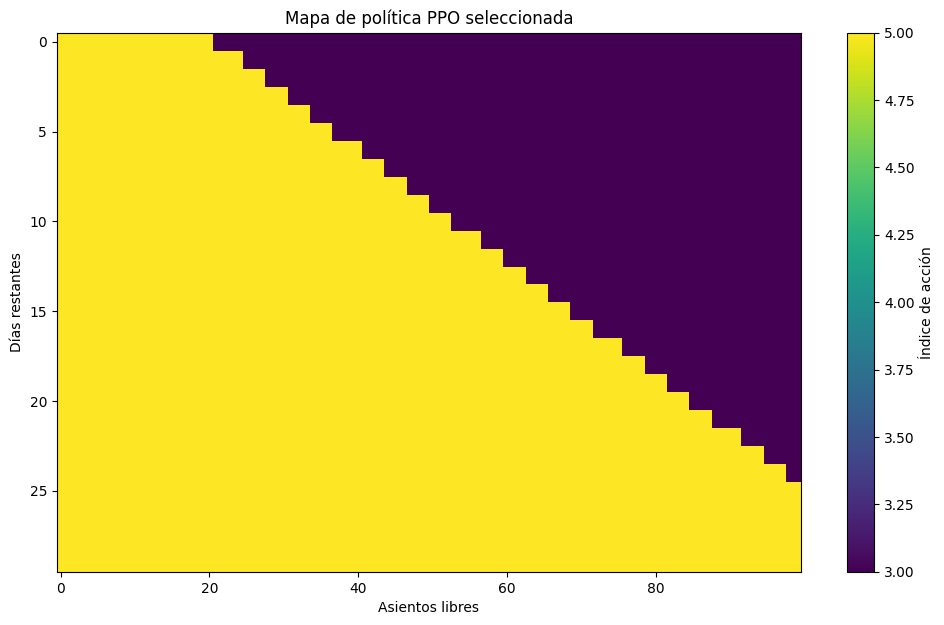

In [ ]:
politica_ppo = np.zeros((MAX_DIAS + 1, CAPACIDAD + 1), dtype=int)

estados_batch = []
coordenadas = []

for dias in range(1, MAX_DIAS + 1):
    precio_base = env_dp.precio_base(dias)
    precio_norm = float(np.clip(precio_base / ESCALA_PRECIO_TRAIN, 0.0, 1.0))
    for asientos_libres in range(1, CAPACIDAD + 1):
        ocupacion = 1.0 - (asientos_libres / CAPACIDAD)
        estados_batch.append([dias / MAX_DIAS, ocupacion, precio_norm])
        coordenadas.append((dias, asientos_libres))

estados_array = np.array(estados_batch, dtype=np.float32)
acciones_batch, _ = modelo_ppo_best.predict(estados_array, deterministic=True)

for (dias, asientos_libres), accion in zip(coordenadas, acciones_batch):
    politica_ppo[dias, asientos_libres] = int(accion)


politica_util = politica_ppo[1:, 1:]
acciones_ppo, frecuencias_ppo = np.unique(politica_util, return_counts=True)

df_distribucion_ppo = pd.DataFrame({
    "accion": acciones_ppo,
    "multiplicador": [float(env_dp.multiplicadores[a]) for a in acciones_ppo],
    "estados": frecuencias_ppo,
    "porcentaje": (frecuencias_ppo / politica_util.size * 100.0)
})

display(df_distribucion_ppo.round(2))
print(f"Número de acciones distintas: {len(acciones_ppo)}")

porcentaje_neutral = df_distribucion_ppo.loc[df_distribucion_ppo['accion'] == 4, 'porcentaje'].sum()
print(f"Porcentaje de acción neutral 1.0x: {porcentaje_neutral:.2f}%")

filas_temporales = []

for dias in range(1, MAX_DIAS + 1):
    acciones_dia = politica_ppo[dias, 1:]
    multiplicadores_dia = env_dp.multiplicadores[acciones_dia]

    filas_temporales.append({
        "dias_restantes": dias,
        "multiplicador_medio": float(np.mean(multiplicadores_dia)),
        "multiplicador_minimo": float(np.min(multiplicadores_dia)),
        "multiplicador_maximo": float(np.max(multiplicadores_dia)),
        "acciones_distintas": int(len(np.unique(acciones_dia))),
    })

df_politica_temporal = pd.DataFrame(filas_temporales)
display(df_politica_temporal.round(3))

politica_dp_util = politica_dp[1:, 1:]
coincidencias = (politica_ppo[1:, 1:] == politica_dp_util)
porcentaje_coincidencia_dp = float(coincidencias.mean() * 100.0)

print(f"Coincidencia de acciones PPO vs DP: {porcentaje_coincidencia_dp:.2f}%")

plt.figure(figsize=(12, 7))
plt.imshow(politica_util[::-1, :], aspect="auto")
plt.xlabel("Asientos libres")
plt.ylabel("Días restantes")
plt.title("Mapa de política PPO seleccionada")
plt.colorbar(label="Índice de acción")
plt.show()

# EXPORTACIÓN

## Exportación de resultados

Generación de los ficheros finales utilizados para el análisis posterior.

In [ ]:
ruta_export = (
    BASE_DIR / "export"
)

ruta_export.mkdir(
    parents=True,
    exist_ok=True,
)

tabla_final.to_csv(
    ruta_export
    / "resultados_ppo_vs_base_test_por_ruta.csv",
    index=False,
    encoding="utf-8-sig",
)

df_resultados.to_csv(
    ruta_export
    / "resultados_episodios_por_ruta.csv",
    index=False,
    encoding="utf-8-sig",
)

tabla_ic.to_csv(
    ruta_export
    / "intervalos_confianza_por_ruta.csv",
    index=False,
    encoding="utf-8-sig",
)

modelo_ppo_best.save(
    str(
        ruta_export
        / "modelo_renfe_ppo"
    )
)

referencia_precio_train.to_csv(
    ruta_export
    / "referencia_precios_renfe.csv",
    index=False,
    encoding="utf-8-sig",
)

df_completo_desarrollo = pd.concat(
    [
        df_precios_train_pd,
        df_precios_val_pd,
    ],
    ignore_index=True,
)

rutas_disponibles = (
    df_completo_desarrollo[
        [
            COL_ORIGEN,
            COL_DESTINO,
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            COL_ORIGEN,
            COL_DESTINO,
        ]
    )
    .itertuples(
        index=False,
        name=None,
    )
)

rutas_disponibles = list(
    rutas_disponibles
)

cerebro_multiruta = {}

for origen, destino in rutas_disponibles:
    try:
        referencia_ruta, tarifa_max_ruta = crear_referencia_precio(
            df_completo_desarrollo, origen=origen, destino=destino
        )

        precios_base_diarios = {
            str(int(fila["lead_time_dias"])): float(fila["precio_base"])
            for _, fila in referencia_ruta.iterrows()
        }

        # Vectorización ultra-rápida para la exportación
        estados_export = []
        coords_export = []

        for dias in range(0, MAX_DIAS + 1):
            precio_base_dia = precios_base_diarios.get(
                str(dias),
                float(referencia_precio_train[referencia_precio_train["lead_time_dias"] == dias]["precio_base"].iloc[0])
            )
            precio_norm = float(np.clip(precio_base_dia / ESCALA_PRECIO_TRAIN, 0.0, 1.0))

            for asientos_libres in range(0, CAPACIDAD + 1):
                ocupacion = 1.0 - (asientos_libres / CAPACIDAD)
                estados_export.append([dias / MAX_DIAS, ocupacion, precio_norm])
                coords_export.append(f"{dias}_{asientos_libres}")

        estados_array_exp = np.array(estados_export, dtype=np.float32)
        acciones_exp, _ = modelo_ppo_best.predict(estados_array_exp, deterministic=True)

        matriz_ruta = {coord: int(acc) for coord, acc in zip(coords_export, acciones_exp)}

        clave_ruta = f"{origen}_{destino}".upper().replace(" ", "_")

        cerebro_multiruta[clave_ruta] = {
            "politica": matriz_ruta,
            "precios_base": precios_base_diarios,
            "tarifa_maxima": float(tarifa_max_ruta),
            "escala_precio": float(ESCALA_PRECIO_TRAIN),
        }

    except (ValueError, KeyError, IndexError) as error:
        print(f"Ruta no exportada {origen}-{destino}: {error}")


with open(
    ruta_export / "cerebro.js",
    "w",
    encoding="utf-8",
) as archivo:

    archivo.write(
        "const CEREBRO_IA = "
        + json.dumps(
            cerebro_multiruta,
            ensure_ascii=False,
        )
        + ";"
    )


df_entrenamiento.to_csv(
    ruta_export
    / "resumen_entrenamiento_ppo.csv",
    index=False,
    encoding="utf-8-sig",
)

df_distribucion_ppo.to_csv(
    ruta_export
    / "distribucion_acciones_ppo.csv",
    index=False,
    encoding="utf-8-sig",
)

df_politica_temporal.to_csv(
    ruta_export
    / "politica_ppo_por_dias.csv",
    index=False,
    encoding="utf-8-sig",
)

tabla_ic_heuristica.to_csv(
    ruta_export
    / "intervalos_confianza_ppo_vs_heuristica.csv",
    index=False,
    encoding="utf-8-sig",
)


metadatos_exportacion = {
    "semilla_global": SEED,
    "capacidad": CAPACIDAD,
    "max_dias": MAX_DIAS,
    "elasticidad_entrenamiento": (
        ELASTICIDAD_NOMINAL
    ),
    "factor_demanda_entrenamiento": (
        FACTOR_DEMANDA_NOMINAL
    ),
    "penalizacion_vacios": (
        PENALIZACION_VACIOS
    ),
    "timesteps_ppo": TIMESTEPS_PPO,
    "coef_reward_shaping": 0.02,
    "semillas_ppo": SEMILLAS_PPO,
    "configuraciones_ppo": CONFIGURACIONES_PPO,
    "evaluaciones_test": N_EVALUACIONES,
    "evaluacion": "por ruta",
    "modelo_ppo": "un único modelo compartido",
    "seleccion_modelo": "mejor reward de VALIDATION",
    "reward_shaping": "potential-based con V_dp de TRAIN",
    "politica_dp": (
        "calculada independientemente "
        "por ruta durante la evaluación"
    ),
    "datos_entorno": (
        "train + validation"
    ),
    "escala_normalizacion": (
        "ESCALA_PRECIO_TRAIN"
    ),
    "fuente_precios_exportacion": (
        "train + validation"
    ),
}

with open(
    ruta_export
    / "metadatos_experimento.json",
    "w",
    encoding="utf-8",
) as archivo:

    json.dump(
        metadatos_exportacion,
        archivo,
        indent=2,
        ensure_ascii=False,
    )

print(
    "Exportación por ruta completada "
    "correctamente."
)

print(
    f"Rutas exportadas: "
    f"{len(cerebro_multiruta)}"
)

Exportación por ruta completada correctamente.
Rutas exportadas: 52
